In [ ]:
$from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/5243project4"
OUTPUT_DIR = f"{PROJECT_DIR}/outputs"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

try:
    import xgboost
    print("xgboost already installed:", xgboost.__version__)
except ImportError:
    %pip install -q xgboost
    import xgboost
    print("xgboost installed:", xgboost.__version__)

import numpy as np
import pandas as pd
import json
import joblib
import time

from scipy import sparse

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

Mounted at /content/drive
xgboost already installed: 3.2.0


In [ ]:
#load processed modeling files from Google Drive
X_train = sparse.load_npz(os.path.join(PROJECT_DIR, "X_train_processed.npz"))
X_test = sparse.load_npz(os.path.join(PROJECT_DIR, "X_test_processed.npz"))

y_train = pd.read_csv(os.path.join(PROJECT_DIR, "y_train.csv"))
y_test = pd.read_csv(os.path.join(PROJECT_DIR, "y_test.csv"))

y_train_vec = y_train["ARR_DEL15"].values
y_test_vec = y_test["ARR_DEL15"].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train_vec.shape)
print("y_test shape:", y_test_vec.shape)
print("Training class balance:")
print(pd.Series(y_train_vec).value_counts(normalize=True))

X_train shape: (1427517, 6214)
X_test shape: (356880, 6214)
y_train shape: (1427517,)
y_test shape: (356880,)
Training class balance:
0    0.802753
1    0.197247
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#define three supervised models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device="cuda",
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
#5fold cross validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
SAMPLE_SIZE = 200000

X_cv_sample, _, y_cv_sample, _ = train_test_split(
    X_train,
    y_train_vec,
    train_size=SAMPLE_SIZE,
    stratify=y_train_vec,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in models.items():
    print(f"\nRunning 5-fold CV for: {name}")
    start_time = time.time()

    scores = cross_validate(
        model,
        X_cv_sample,
        y_cv_sample,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    runtime = time.time() - start_time

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "Runtime Seconds": runtime
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.to_csv(os.path.join(OUTPUT_DIR, "model_cv_results.csv"), index=False)

cv_results_df


Running 5-fold CV for: Logistic Regression

Running 5-fold CV for: Random Forest

Running 5-fold CV for: XGBoost


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Runtime Seconds
0,Logistic Regression,0.898535,0.718010,0.799640,0.756626,0.921509,79.960343
1,Random Forest,0.897695,0.723845,0.784481,0.752182,0.881288,6.176375
2,XGBoost,0.926940,0.908421,0.700195,0.790824,0.931169,7.865897


In [ ]:
#hyperparameter tuning for XGBoost
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import pandas as pd
import os
import time

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=2
)

start_time = time.time()

xgb_search.fit(X_cv_sample, y_cv_sample)

tuning_runtime = time.time() - start_time

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("Best CV F1:")
print(xgb_search.best_score_)

print("Tuning runtime seconds:")
print(tuning_runtime)

In [ ]:
tuning_results_df = pd.DataFrame(xgb_search.cv_results_)
tuning_results_df.to_csv(os.path.join(OUTPUT_DIR, "xgboost_tuning_results.csv"), index=False)

best_params_df = pd.DataFrame([xgb_search.best_params_])
best_params_df["Best CV F1"] = xgb_search.best_score_
best_params_df["Tuning Runtime Seconds"] = tuning_runtime
best_params_df.to_csv(os.path.join(OUTPUT_DIR, "xgboost_best_params.csv"), index=False)

best_params_df

,subsample,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,Best CV F1,Tuning Runtime Seconds
0,0.8,300,10,8,0.05,1.0,0.791955,36.277094


In [ ]:
# Hyperparameter tuning for XGBoost on 200k sample
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import pandas as pd
import os
import time

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=1,      # safer for GPU
    verbose=2
)

start_time = time.time()

xgb_search.fit(X_cv_sample, y_cv_sample)

tuning_runtime = time.time() - start_time

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("Best CV F1:")
print(xgb_search.best_score_)

print("Tuning runtime seconds:")
print(tuning_runtime)

In [ ]:
# Save XGBoost tuning results
tuning_results_df = pd.DataFrame(xgb_search.cv_results_)
tuning_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "xgboost_tuning_results.csv"),
    index=False
)

best_params_df = pd.DataFrame([xgb_search.best_params_])
best_params_df["Best CV F1"] = xgb_search.best_score_
best_params_df["Tuning Runtime Seconds"] = tuning_runtime

best_params_df.to_csv(
    os.path.join(OUTPUT_DIR, "xgboost_best_params.csv"),
    index=False
)

best_params_df

,subsample,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,Best CV F1,Tuning Runtime Seconds
0,0.8,300,10,8,0.05,1.0,0.791955,35.427269


In [ ]:
# Train final XGBoost model on the full training set
best_xgb_model = xgb_search.best_estimator_

start_time = time.time()

best_xgb_model.fit(X_train, y_train_vec)

final_training_runtime = time.time() - start_time

print("Final model training complete.")
print("Training runtime seconds:", final_training_runtime)

Final model training complete.
Training runtime seconds: 2.071974039077759


In [ ]:
# Final test-set evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

y_test_pred = best_xgb_model.predict(X_test)
y_test_proba = best_xgb_model.predict_proba(X_test)[:, 1]

final_results = {
    "Model": "Tuned XGBoost",
    "Test Accuracy": accuracy_score(y_test_vec, y_test_pred),
    "Test Precision": precision_score(y_test_vec, y_test_pred, zero_division=0),
    "Test Recall": recall_score(y_test_vec, y_test_pred, zero_division=0),
    "Test F1": f1_score(y_test_vec, y_test_pred, zero_division=0),
    "Test ROC-AUC": roc_auc_score(y_test_vec, y_test_proba),
    "Final Training Runtime Seconds": final_training_runtime
}

final_results_df = pd.DataFrame([final_results])

final_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_test_results.csv"),
    index=False
)

final_results_df

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Final Training Runtime Seconds
0,Tuned XGBoost,0.927687,0.910524,0.702418,0.793046,0.937281,2.071974


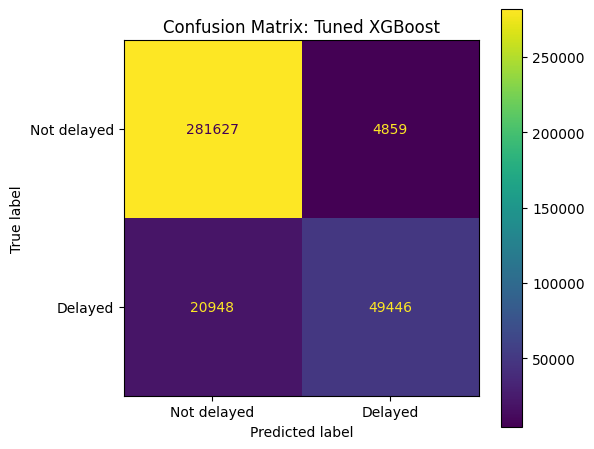

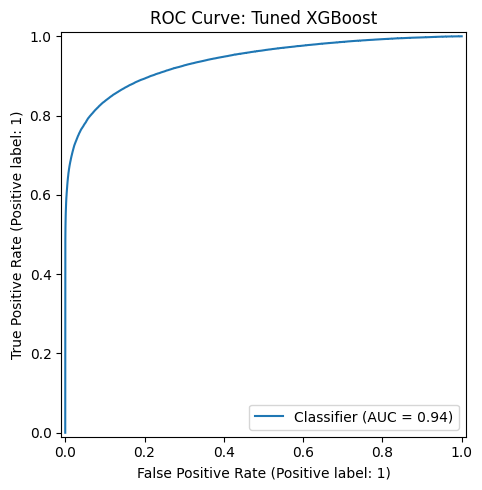

In [ ]:
# Save final model plots
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Confusion matrix
cm = confusion_matrix(y_test_vec, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not delayed", "Delayed"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix: Tuned XGBoost")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "confusion_matrix_xgboost.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test_vec,
    y_test_proba,
    ax=ax
)
plt.title("ROC Curve: Tuned XGBoost")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "roc_curve_xgboost.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Save final trained model
import joblib

joblib.dump(
    best_xgb_model,
    os.path.join(OUTPUT_DIR, "final_xgboost_model.joblib")
)

print("Final model saved.")

Final model saved.


In [ ]:
# Create final model comparison table for report and slides
final_comparison_df = cv_results_df.copy()

final_comparison_df["Evaluation Setting"] = "5-fold CV on 200k training sample"

# Add final tuned XGBoost test result as another row
final_test_row = pd.DataFrame([{
    "Model": "Tuned XGBoost",
    "CV Accuracy": final_results_df.loc[0, "Test Accuracy"],
    "CV Precision": final_results_df.loc[0, "Test Precision"],
    "CV Recall": final_results_df.loc[0, "Test Recall"],
    "CV F1": final_results_df.loc[0, "Test F1"],
    "CV ROC-AUC": final_results_df.loc[0, "Test ROC-AUC"],
    "Runtime Seconds": final_results_df.loc[0, "Final Training Runtime Seconds"],
    "Evaluation Setting": "Final evaluation on full test set"
}])

final_comparison_df = pd.concat(
    [final_comparison_df, final_test_row],
    ignore_index=True
)

final_comparison_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_model_comparison_table.csv"),
    index=False
)

final_comparison_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Runtime Seconds,Evaluation Setting
0,Logistic Regression,0.898535,0.718010,0.799640,0.756626,0.921509,79.960343,5-fold CV on 200k training sample
1,Random Forest,0.897695,0.723845,0.784481,0.752182,0.881288,6.176375,5-fold CV on 200k training sample
2,XGBoost,0.926940,0.908421,0.700195,0.790824,0.931169,7.865897,5-fold CV on 200k training sample
3,Tuned XGBoost,0.927687,0.910524,0.702418,0.793046,0.937281,2.071974,Final evaluation on full test set


Number of feature names: 6214
Number of X_train columns: 6214


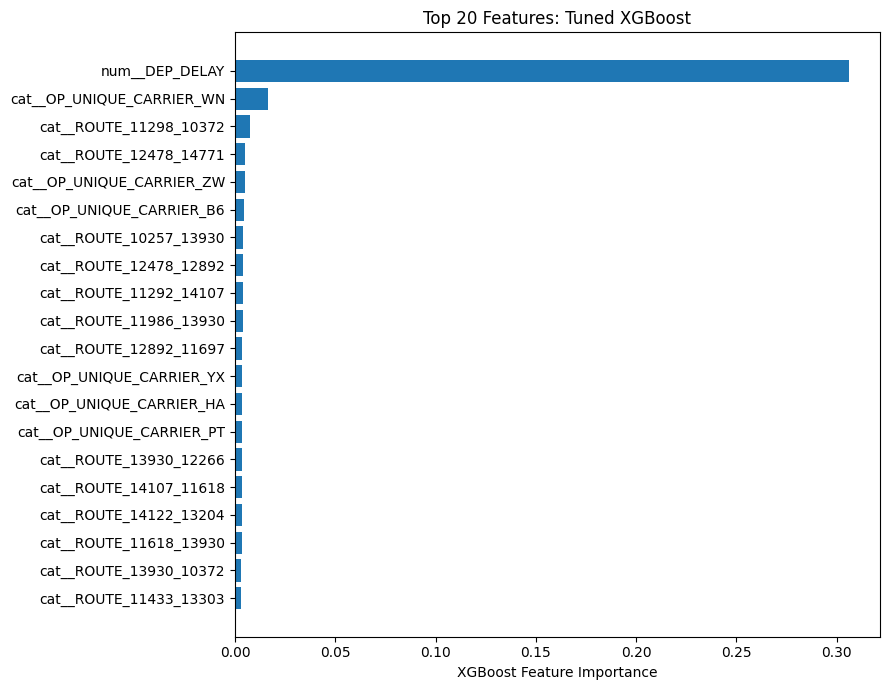

,Feature,Importance
5,num__DEP_DELAY,0.306298
30,cat__OP_UNIQUE_CARRIER_WN,0.016469
1638,cat__ROUTE_11298_10372,0.007252
2953,cat__ROUTE_12478_14771,0.005206
33,cat__OP_UNIQUE_CARRIER_ZW,0.004836
16,cat__OP_UNIQUE_CARRIER_B6,0.004447
109,cat__ROUTE_10257_13930,0.004245
2927,cat__ROUTE_12478_12892,0.004233
1584,cat__ROUTE_11292_14107,0.003814
2350,cat__ROUTE_11986_13930,0.003806


In [ ]:
# Feature importance with recovered processed feature names
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed feature names
feature_names_path = os.path.join(PROJECT_DIR, "processed_feature_names.csv")
feature_names_df = pd.read_csv(feature_names_path)

feature_names = feature_names_df["feature_name"].values

print("Number of feature names:", len(feature_names))
print("Number of X_train columns:", X_train.shape[1])

assert len(feature_names) == X_train.shape[1], "Feature name count does not match X_train columns."

# Extract XGBoost feature importance
importances = best_xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Save full feature importance table
feature_importance_df.to_csv(
    os.path.join(OUTPUT_DIR, "xgboost_feature_importance_named.csv"),
    index=False
)

# Plot top 20 features
top_n = 20
top_features = feature_importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("XGBoost Feature Importance")
plt.title("Top 20 Features: Tuned XGBoost")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "xgboost_top20_feature_importance_named.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

feature_importance_df.head(20)

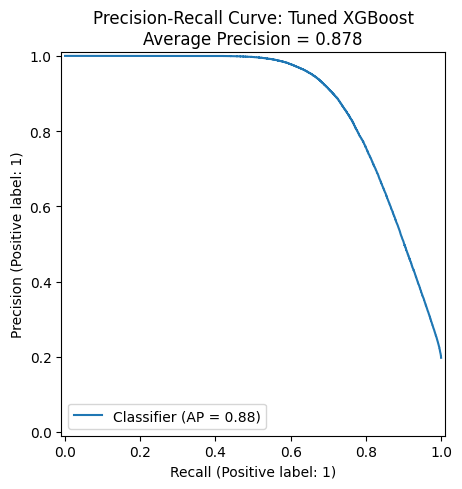

Average Precision: 0.8782712518893895


In [ ]:
# Precision-Recall curve for tuned XGBoost
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

avg_precision = average_precision_score(y_test_vec, y_test_proba)

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test_vec,
    y_test_proba,
    ax=ax
)
plt.title(f"Precision-Recall Curve: Tuned XGBoost\nAverage Precision = {avg_precision:.3f}")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "precision_recall_curve_xgboost.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Average Precision:", avg_precision)

In [ ]:
# Threshold tradeoff table
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_rows = []

for threshold in thresholds:
    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_vec, y_pred_threshold),
        "Precision": precision_score(y_test_vec, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test_vec, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test_vec, y_pred_threshold, zero_division=0)
    })

threshold_tradeoff_df = pd.DataFrame(threshold_rows)

threshold_tradeoff_df.to_csv(
    os.path.join(OUTPUT_DIR, "xgboost_threshold_tradeoff.csv"),
    index=False
)

threshold_tradeoff_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.3,0.920931,0.820516,0.766898,0.792801
1,0.4,0.926451,0.873561,0.733259,0.797285
2,0.5,0.927687,0.910524,0.702418,0.793046
3,0.6,0.926748,0.939706,0.671733,0.783439
4,0.7,0.923425,0.961863,0.637043,0.766459


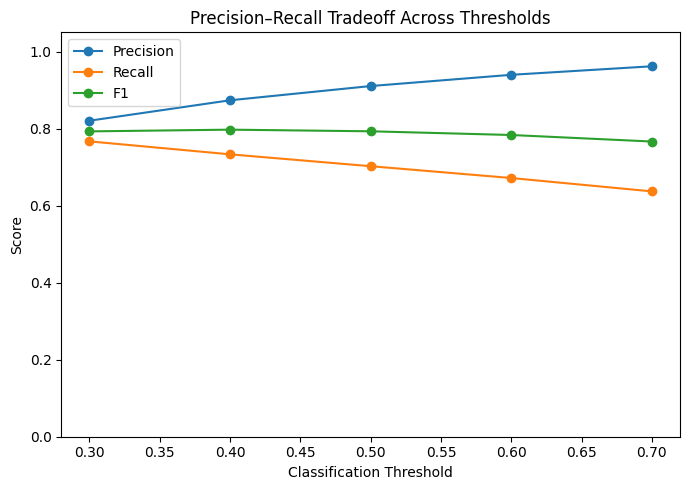

In [ ]:
# Threshold tradeoff plot
plt.figure(figsize=(7, 5))

plt.plot(threshold_tradeoff_df["Threshold"], threshold_tradeoff_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_tradeoff_df["Threshold"], threshold_tradeoff_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_tradeoff_df["Threshold"], threshold_tradeoff_df["F1"], marker="o", label="F1")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Tradeoff Across Thresholds")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "xgboost_threshold_tradeoff_plot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Export all plots/tables as PNG
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix, average_precision_score

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def save_table_png(df, filename, title=None, max_rows=None, font_size=8, scale_y=1.35):
    """
    Save a pandas DataFrame as a clean PNG table.
    """
    table_df = df.copy()

    if max_rows is not None:
        table_df = table_df.head(max_rows)

    # Round numeric columns for readability
    for col in table_df.columns:
        if pd.api.types.is_numeric_dtype(table_df[col]):
            table_df[col] = table_df[col].round(4)

    # Convert all values to string
    table_df = table_df.astype(str)

    n_rows, n_cols = table_df.shape
    fig_width = max(8, n_cols * 1.6)
    fig_height = max(2.2, (n_rows + 1) * 0.45)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=12, fontweight="bold", pad=12)

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center",
        cellLoc="center",
        colLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, scale_y)

    for key, cell in table.get_celld().items():
        cell.set_linewidth(0.5)
        if key[0] == 0:
            cell.set_text_props(weight="bold")

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_path}")

def wrap_labels(labels, width=32):
    return ["\n".join(textwrap.wrap(str(label), width=width)) for label in labels]


# 1. Cross-validation model comparison table
save_table_png(
    cv_results_df,
    "person4_cv_model_comparison_table.png",
    title="5-Fold Cross-Validation Model Comparison",
    font_size=8
)

# 2. XGBoost tuning results table
# Usually this table is very large, so export top 15 rows if sorted.
if "rank_test_score" in tuning_results_df.columns:
    tuning_export_df = tuning_results_df.sort_values("rank_test_score").head(15)
else:
    tuning_export_df = tuning_results_df.head(15)

save_table_png(
    tuning_export_df,
    "person4_xgboost_tuning_results_top15_table.png",
    title="XGBoost Tuning Results: Top 15 Settings",
    font_size=6,
    scale_y=1.25
)

# 3. XGBoost best parameters table
save_table_png(
    best_params_df,
    "person4_xgboost_best_params_table.png",
    title="Best XGBoost Hyperparameters",
    font_size=8
)

# 4. Final test results table
save_table_png(
    final_results_df,
    "person4_final_test_results_table.png",
    title="Final Test-Set Results: Tuned XGBoost",
    font_size=8
)

# 5. Confusion matrix
cm = confusion_matrix(y_test_vec, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not delayed", "Delayed"]
)
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix: Tuned XGBoost")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "person4_confusion_matrix_xgboost.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("Saved:", os.path.join(OUTPUT_DIR, "person4_confusion_matrix_xgboost.png"))

# 6. ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test_vec,
    y_test_proba,
    ax=ax
)
plt.title("ROC Curve: Tuned XGBoost")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "person4_roc_curve_xgboost.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("Saved:", os.path.join(OUTPUT_DIR, "person4_roc_curve_xgboost.png"))


# 7. Final model comparison table
save_table_png(
    final_comparison_df,
    "person5_final_model_comparison_table.png",
    title="Final Model Comparison",
    font_size=7,
    scale_y=1.3
)

# 8. Feature importance full / top table
save_table_png(
    feature_importance_df.head(20),
    "person5_top20_feature_importance_table.png",
    title="Top 20 XGBoost Feature Importances",
    font_size=7,
    scale_y=1.25
)

# 9. Feature importance bar chart
top_features = feature_importance_df.sort_values("Importance", ascending=False).head(20).copy()
top_features = top_features.sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    wrap_labels(top_features["Feature"], width=35),
    top_features["Importance"]
)
ax.set_xlabel("XGBoost Feature Importance")
ax.set_title("Top 20 Features: Tuned XGBoost")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "person5_top20_feature_importance_plot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("Saved:", os.path.join(OUTPUT_DIR, "person5_top20_feature_importance_plot.png"))

# 10. Precision-Recall curve
avg_precision = average_precision_score(y_test_vec, y_test_proba)

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test_vec,
    y_test_proba,
    ax=ax
)
plt.title(f"Precision-Recall Curve: Tuned XGBoost\nAverage Precision = {avg_precision:.3f}")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "person5_precision_recall_curve_xgboost.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("Saved:", os.path.join(OUTPUT_DIR, "person5_precision_recall_curve_xgboost.png"))

# 11. Threshold tradeoff table
save_table_png(
    threshold_tradeoff_df,
    "person5_threshold_tradeoff_table.png",
    title="Threshold Tradeoff Table",
    font_size=8
)


print("\nDone. All Person 4 and Person 5 PNG files are saved in the output/ folder.")

Saved: output/person4_cv_model_comparison_table.png
Saved: output/person4_xgboost_tuning_results_top15_table.png
Saved: output/person4_xgboost_best_params_table.png
Saved: output/person4_final_test_results_table.png
Saved: output/person4_confusion_matrix_xgboost.png
Saved: output/person4_roc_curve_xgboost.png
Saved: output/person5_final_model_comparison_table.png
Saved: output/person5_top20_feature_importance_table.png
Saved: output/person5_top20_feature_importance_plot.png
Saved: output/person5_precision_recall_curve_xgboost.png
Saved: output/person5_threshold_tradeoff_table.png

Done. All Person 4 and Person 5 PNG files are saved in the output/ folder.


In [ ]:
from google.colab import drive
import os
import shutil
import glob

drive.mount('/content/drive')

source_folder = "/content/output"

destination_folder = "/content/drive/MyDrive/5243project4/outputs"

os.makedirs(destination_folder, exist_ok=True)

for item in glob.glob(os.path.join(source_folder, "*")):
    item_name = os.path.basename(item)
    destination_path = os.path.join(destination_folder, item_name)

    if os.path.isdir(item):
        if os.path.exists(destination_path):
            shutil.rmtree(destination_path)
        shutil.copytree(item, destination_path)
    else:
        shutil.copy2(item, destination_path)

print("Done. Files copied to:")
print(destination_folder)
print("\nFiles now in Google Drive outputs folder:")
print(os.listdir(destination_folder))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done. Files copied to:
/content/drive/MyDrive/5243project4/outputs

Files now in Google Drive outputs folder:
['airportid1.csv', 'airportid2.csv', 'airportid3.csv', 'flight_delay_raw_2025_Q1.csv.zip', 'flight_delay_clean_2025_Q1.csv.zip', 'debug_model_results.csv', 'model_cv_results.csv', 'xgboost_tuning_results.csv', 'xgboost_best_params.csv', 'final_test_results.csv', 'confusion_matrix_xgboost.png', 'roc_curve_xgboost.png', 'final_xgboost_model.joblib', 'final_model_comparison_table.csv', 'xgboost_feature_importance.csv', 'xgboost_top20_feature_importance.png', 'precision_recall_curve_xgboost.png', 'xgboost_threshold_tradeoff.csv', 'xgboost_threshold_tradeoff_plot.png', 'xgboost_feature_importance_named.csv', 'xgboost_top20_feature_importance_named.png', 'person5_final_model_comparison_table.png', 'person4_final_test_results_table.png', 'person5_threshold_t